<a href="https://colab.research.google.com/github/AditiAICodes/Autobahn-Data-Analysis/blob/main/Phase_2/Phase_2_Refinery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Raw data → DataFrame → CSV storage → Reload → Filter rules → Subset (speeders) → Analysis (stats, insights)

import pandas as pd
import random
import time

print("\033[1m--- MUNICH DATA REFINERY BOOTING UP --- \033[0m")
time.sleep(1)
print("Generating 500 rows of historic Autobahn telemetry data...")
time.sleep(1)

# We are building a massive dictionary of data
data = {
    "Car_ID": [f"Porsche_{i}" for i in range(1, 501)],
    "Speed_kmh": [random.randint(90, 260) for _ in range(500)],
    "Engine_Temp_C": [random.randint(85, 135) for _ in range(500)],
    "Driver_Mode": [random.choice(["Comfort", "Sport", "Track"]) for _ in range(500)]
}

# Pandas turns the dictionary into a magical table called a "DataFrame"
#In Python, when you put a dot (.) after a variable, you are pressing a button on that variable to make it do an action. We call these actions Methods.
#If you want to save it, you press its df.to_csv() button.

df = pd.DataFrame(data)

# We save it as a CSV file
df.to_csv("autobahn_history.csv", index=False)

print("\033[92m✅ SUCCESS: autobahn_history.csv has been saved to your Colab folder!\033[0m")
print("Total rows generated: 500")

--- MUNICH DATA REFINERY BOOTING UP --- 
Generating 500 rows of historic Autobahn telemetry data...
✅ SUCCESS: autobahn_history.csv has been saved to your Colab folder!
Total rows generated: 500


In [2]:
# 1. The Reader: We tell pandas to open the CSV file and turn it back into a DataFrame
df = pd.read_csv("autobahn_history.csv")

# 2. The Scanner: We peek at the top 5 rows only
print("\033[94m[ AUTOBAHN DATABASE: TOP 5 ROWS ]\033[0m\n")
print(df.head())

[ AUTOBAHN DATABASE: TOP 5 ROWS ]

      Car_ID  Speed_kmh  Engine_Temp_C Driver_Mode
0  Porsche_1        116            110     Comfort
1  Porsche_2        123             99       Track
2  Porsche_3        211            113       Track
3  Porsche_4        260            100       Track
4  Porsche_5        135             95       Sport


In [3]:
# We ask Pandas to sort the entire database by Speed.

fastest_cars = df.sort_values(by="Speed_kmh", ascending=False)

print("\033[91m[ 🚨 AUTOBAHN SPEED CAMERAS: TOP 3 FASTEST PORSCHES ]\033[0m\n")


print(fastest_cars.head(3))

[ 🚨 AUTOBAHN SPEED CAMERAS: TOP 3 FASTEST PORSCHES ]

          Car_ID  Speed_kmh  Engine_Temp_C Driver_Mode
357  Porsche_358        260             97       Track
3      Porsche_4        260            100       Track
68    Porsche_69        260            121     Comfort


In [4]:
# 1. VECTORIZED BOOLEAN INDEXING (The Logic Mask)
# We utilize bitwise operators (&) to create a logical mask for multi-conditional filtering.
# Intent: Isolate high-performance outliers (Speed > 240) specific to 'Track' mode.
rule = (df["Speed_kmh"] > 240) & (df["Driver_Mode"] == "Track")

# 2. DATA SUBSET EXTRACTION
# Applying the boolean mask to the primary DataFrame to generate a risk-specific subset.
speeders = df[rule]

print("\033[93m[ 🚔 MUNICH HIGHWAY PATROL: TRACK-MODE SPEEDERS ]\033[0m\n")
print(speeders)
print(f"\nTotal Speeders Found: {len(speeders)}")

[ 🚔 MUNICH HIGHWAY PATROL: TRACK-MODE SPEEDERS ]

          Car_ID  Speed_kmh  Engine_Temp_C Driver_Mode
3      Porsche_4        260            100       Track
96    Porsche_97        259            128       Track
132  Porsche_133        247            125       Track
174  Porsche_175        242            120       Track
178  Porsche_179        258            133       Track
204  Porsche_205        244            130       Track
249  Porsche_250        241            111       Track
339  Porsche_340        243             86       Track
346  Porsche_347        255             94       Track
357  Porsche_358        260             97       Track
363  Porsche_364        250             94       Track
373  Porsche_374        245            131       Track
392  Porsche_393        258             88       Track
403  Porsche_404        247            123       Track
437  Porsche_438        256             94       Track
451  Porsche_452        258             88       Track
475  Porsche_47

In [5]:
df.describe()
#describe() is a Pandas DataFrame method

#a built-in function attached to DataFrames that automatically calculates statistics

,Speed_kmh,Engine_Temp_C
count,500.000000,500.000000
mean,175.814000,110.374000
std,49.848462,14.922852
min,90.000000,85.000000
25%,135.000000,97.750000
50%,178.000000,111.000000
75%,216.000000,124.250000
max,260.000000,135.000000


In [6]:
# df.describe()       → Full dataset (500 rows)   → global behavior
# speeders.describe() → Filtered dataset (31 rows) → targeted behavior
# Note: count = number of rows in the current dataset (not always 500)
speeders.describe()


,Speed_kmh,Engine_Temp_C
count,19.000000,19.000000
mean,251.578947,108.526316
std,7.026267,18.243320
min,241.000000,86.000000
25%,245.000000,94.000000
50%,252.000000,100.000000
75%,258.000000,126.500000
max,260.000000,135.000000


In [7]:
# sort_values() → built-in pandas method to sort a DataFrame
# by=           → column used for sorting (the “rule” for ordering)

speeders.sort_values(by="Speed_kmh", ascending=False).head(10)

,Car_ID,Speed_kmh,Engine_Temp_C,Driver_Mode
3,Porsche_4,260,100,Track
485,Porsche_486,260,96,Track
357,Porsche_358,260,97,Track
96,Porsche_97,259,128,Track
451,Porsche_452,258,88,Track
392,Porsche_393,258,88,Track
178,Porsche_179,258,133,Track
437,Porsche_438,256,94,Track
346,Porsche_347,255,94,Track
488,Porsche_489,252,135,Track


In [8]:
# 1. CATEGORICAL FREQUENCY DISTRIBUTION
# Performing an frequency analysis on 'Driver_Mode' to audit class distribution.
# This ensures our dataset maintains balanced categories for future model training.
mode_distribution = df["Driver_Mode"].value_counts()

print("\033[94m[ 📊 DATA AUDIT: DRIVER MODE DISTRIBUTION ]\033[0m\n")
print(mode_distribution)



[ 📊 DATA AUDIT: DRIVER MODE DISTRIBUTION ]

Driver_Mode
Track      187
Comfort    164
Sport      149
Name: count, dtype: int64


In [9]:
# 1. MULTI-VARIATE THRESHOLD ANALYSIS
# Identifying the 'Danger Zone' by isolating the intersection of two critical telemetry peaks.

danger_mask = (df["Speed_kmh"] > 230) & (df["Engine_Temp_C"] > 120)

# 2. ANOMALY DETECTION SUBSET
# Extracting high-risk data points to analyze potential mechanical failure correlations.
danger = df[danger_mask]

print("\033[91m[ 🚨 SYSTEM ALERT: CRITICAL THERMAL-VELOCITY OVERLAP ]\033[0m\n")
print(danger)

[ 🚨 SYSTEM ALERT: CRITICAL THERMAL-VELOCITY OVERLAP ]

          Car_ID  Speed_kmh  Engine_Temp_C Driver_Mode
48    Porsche_49        232            134       Track
68    Porsche_69        260            121     Comfort
71    Porsche_72        243            130     Comfort
93    Porsche_94        240            124       Track
96    Porsche_97        259            128       Track
122  Porsche_123        239            128       Track
132  Porsche_133        247            125       Track
178  Porsche_179        258            133       Track
184  Porsche_185        246            128     Comfort
199  Porsche_200        234            133       Track
204  Porsche_205        244            130       Track
221  Porsche_222        242            125       Sport
253  Porsche_254        234            130     Comfort
260  Porsche_261        242            129     Comfort
300  Porsche_301        256            122     Comfort
312  Porsche_313        260            127       Sport
332  Porsc

In [10]:
# 1. DATA PERSISTENCE: EXPORTING REFINED SUBSET
# Serializing the filtered 'speeders' DataFrame into a permanent CSV format.

speeders.to_csv("track_speeders.csv", index=False)


[  MUNICH VISUAL DASHBOARD ONLINE ]



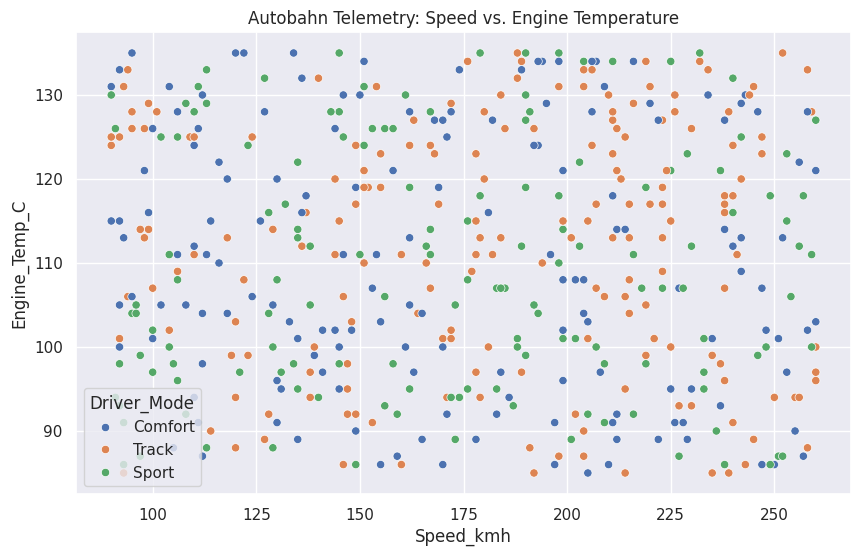

In [11]:

import matplotlib.pyplot as plt
import seaborn as sns

print("\033[95m[  MUNICH VISUAL DASHBOARD ONLINE ]\033[0m\n")


sns.set_theme(style="darkgrid")





# Create the Canvas (Width=10, Height=6)
plt.figure(figsize=(10, 6))


# We tell Seaborn: "Use our 'df', put Speed on the bottom, Temp on the side"
# 'hue' tells it to color-code the dots based on the Driver Mode
#data is a parameter name inside seaborn’s function
#def scatterplot(data, x, y, hue):
sns.scatterplot(data=df, x="Speed_kmh", y="Engine_Temp_C", hue="Driver_Mode", palette="deep")


plt.title("Autobahn Telemetry: Speed vs. Engine Temperature")
plt.show()

[ 🥧 MUNICH DASHBOARD: DRIVER MODE DISTRIBUTION ]



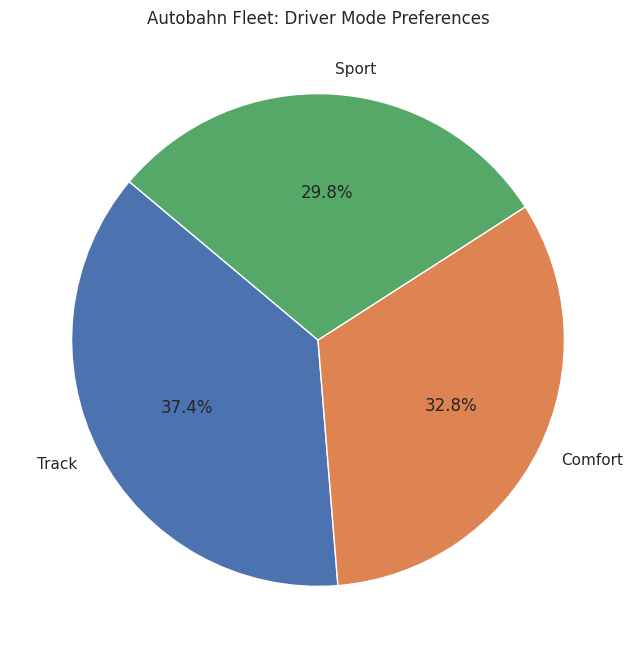

In [12]:
#Out of all cars, how many are in each Driver Mode?

print("\033[96m[ 🥧 MUNICH DASHBOARD: DRIVER MODE DISTRIBUTION ]\033[0m\n")


mode_counts = df["Driver_Mode"].value_counts()


plt.figure(figsize=(8, 8))

# We tell matplotlib to draw a pie chart!
# autopct='%1.1f%%' automatically calculates the percentages
plt.pie(mode_counts, labels=mode_counts.index, autopct='%1.1f%%', startangle=140, colors=['#4C72B0', '#DD8452', '#55A868'])


plt.title("Autobahn Fleet: Driver Mode Preferences")
plt.show()

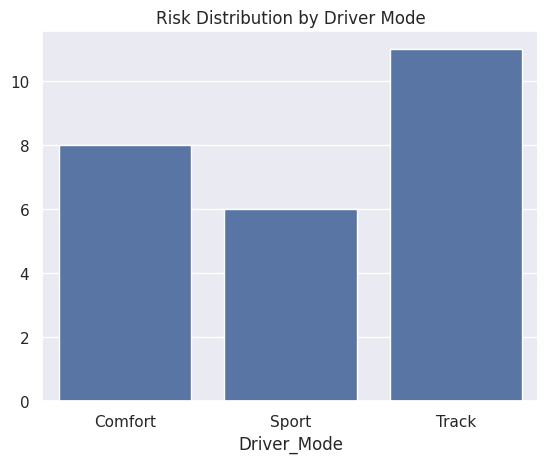

In [13]:
#Which driving modes are actually risky based on speed + temperature?

import seaborn as sns
import matplotlib.pyplot as plt

#create a new column inside df called Risk

risk = (df["Speed_kmh"] > 230) & (df["Engine_Temp_C"] > 120)
#The thing receiving the data must always be on the left. The data being poured must always be on the right
df["Risk"] = risk

#group by Driver_Mode select Risk column  apply sum


risk_counts = df.groupby("Driver_Mode")["Risk"].sum()


sns.barplot(x=risk_counts.index, y=risk_counts.values)
plt.title("Risk Distribution by Driver Mode")
plt.show()




In [16]:
# 1. FEATURE SELECTION: SERIES EXTRACTION
# Isolating the 'Speed_kmh' vector from the primary DataFrame for independent analysis.
# This converts the 2D table column into a 1D Pandas Series.
df["Speed_kmh"]

# Preparing specific telemetry features for statistical modeling or visualization.

,Speed_kmh
0,116
1,123
2,211
3,260
4,135
...,...
495,199
496,197
497,215
498,232


In [17]:
import numpy as np

print("\033[91m[ ⚠️ INITIATING SABOTAGE PROTOCOL: CORRUPTING DATA... ]\033[0m\n")

# 1. The Broken Sensors (Injecting Blank Spaces)
# We randomly select 20 cars and completely delete their Engine Temperature
df.loc[df.sample(20).index, "Engine_Temp_C"] = np.nan

# 2. The Typo (Human Error)
# We randomly select 15 cars and misspell 'Track' as 'Trakk'
df.loc[df.sample(15).index, "Driver_Mode"] = "Trakk"

# 3. The Glitch (Impossible Math)
# We randomly select 5 cars and make them go 999 km/h
df.loc[df.sample(5).index, "Speed_kmh"] = 999

print("SUCCESS: Data successfully corrupted! \n")

# 4. The Damage Report
# .isna().sum() is a built-in scanner that counts exactly how many blank spaces exist in each column
print("\033[93m[ DAMAGE REPORT: BLANK SPACES FOUND ]\033[0m")
print(df.isna().sum())

[ ⚠️ INITIATING SABOTAGE PROTOCOL: CORRUPTING DATA... ]

SUCCESS: Data successfully corrupted! 

[ DAMAGE REPORT: BLANK SPACES FOUND ]
Car_ID            0
Speed_kmh         0
Engine_Temp_C    20
Driver_Mode       0
Risk              0
dtype: int64


In [18]:
print("\033[92m[ 🛠️ INITIATING REPAIR PROTOCOL: PATCHING VOIDS ]\033[0m\n")


avg_temp = df["Engine_Temp_C"].mean()
print(f"Calculated Fleet Average: {avg_temp:.1f}°C")

# We target the broken column, tell it to fill the NA (NaN) voids with the average, and save it!
df["Engine_Temp_C"] = df["Engine_Temp_C"].fillna(avg_temp)

print("SUCCESS: Engine Temperatures Stabilized! 🩹\n")

# Final Radar Scan
print("\033[96m[ FINAL DAMAGE REPORT ]\033[0m")
print(df.isna().sum())

[ 🛠️ INITIATING REPAIR PROTOCOL: PATCHING VOIDS ]

Calculated Fleet Average: 110.4°C
SUCCESS: Engine Temperatures Stabilized! 🩹

[ FINAL DAMAGE REPORT ]
Car_ID           0
Speed_kmh        0
Engine_Temp_C    0
Driver_Mode      0
Risk             0
dtype: int64


In [19]:
print("\033[93m[ 🔍 INITIATING LOGICAL SWEEP: HUNTING TYPOS & GLITCHES ]\033[0m\n")

# --- FIX 1: THE TYPO ("Trakk") ---
print("1. Scanning Driver_Mode for typos...")
print("Before fix:")
print(df["Driver_Mode"].value_counts())

# The Fix: We tell Pandas to find every instance of "Trakk" and overwrite it with "Track"
df["Driver_Mode"] = df["Driver_Mode"].replace("Trakk", "Track")
print("\nTypo Patched! ✅")

# --- FIX 2: THE GLITCH (999 km/h) ---
print("\n2. Scanning Speed_kmh for impossible numbers...")
# We use our police radar rule to find the glitches!
glitch_rule = df["Speed_kmh"] == 999
glitches = df[glitch_rule]
print(f"Found {len(glitches)} cars breaking the laws of physics!")

# The Fix: We use our GPS locator (.loc) to target those specific broken speeds
# and safely reset them to a normal high speed (e.g., 250 km/h)
df.loc[df["Speed_kmh"] == 999, "Speed_kmh"] = 250
print("Speed Sensors Recalibrated! ✅\n")

# --- FINAL VERIFICATION ---
print("\033[92m[ 🏁 ALL SYSTEMS GREEN. DATABASE IS 100% CLEAN. ]\033[0m")

[ 🔍 INITIATING LOGICAL SWEEP: HUNTING TYPOS & GLITCHES ]

1. Scanning Driver_Mode for typos...
Before fix:
Driver_Mode
Track      181
Comfort    159
Sport      145
Trakk       15
Name: count, dtype: int64

Typo Patched! ✅

2. Scanning Speed_kmh for impossible numbers...
Found 5 cars breaking the laws of physics!
Speed Sensors Recalibrated! ✅

[ 🏁 ALL SYSTEMS GREEN. DATABASE IS 100% CLEAN. ]
